# Higher-Order Singular-Value Derivatives

In [1]:
# Author: Róisín Luo

In [2]:
import torch
import matplotlib.pyplot as plt
import math
import numpy as np
import os
from tqdm.auto import tqdm
import seaborn as sns
import pandas as pd


plt.style.use('ggplot')
torch.set_default_dtype(torch.float64)

# Vectorization

In [3]:
def vec(x, column_major=True):
    if column_major:
        return x.t().flatten()
    else:
        return x.flatten()

def unvec(x, shape, column_major=True):
    if column_major:
        return x.unflatten(dim=0, sizes=shape[::-1]).t()
    else:
        return x.unflatten(dim=0, sizes=shape)

# Singular-Value Jacobian

In [4]:
def get_singularvalue_Jacobian(A, k):    
    m, n = A.shape
         
    U, S, Vh = torch.linalg.svd(A.detach(), full_matrices=True)

    sigma_k = S[k - 1]  
    u_k = U[:, k - 1] 
    v_k = Vh[k - 1, :] 


    def sigma_func(X):
        U, S, Vh = torch.linalg.svd(X, full_matrices=True)
        return S[k - 1]

    y = sigma_func(A)

    J_autograd = torch.autograd.grad(y, A, create_graph=True)[0] 
    J_theoretical = torch.outer(u_k, v_k)

    J_error = torch.norm(J_theoretical - J_autograd)

    return k, J_theoretical.detach().numpy(), J_autograd.detach().numpy(), J_error.item()

def get_singularvalue_Jacobians(A): 
    r = torch.linalg.matrix_rank(A)
    res_list=[]
    
    for k in range(1, r+1):
        A_local = A.clone().detach()
        A_local.requires_grad_()    
        res = get_singularvalue_Jacobian(A_local, k)
        res_list.append(res)
        
    return res_list

## Plotting Singular-Value Jacobian

In [5]:
r"""
    res_list in the format [(k, theoretical, autograd, error), ... ]
"""
def plot_pairs(res_list, saveto=None, pairs_per_row=2, show_cbar=True, cmap="viridis"):

    
    n_pairs = len(res_list)
    n_rows = max(1, math.ceil(n_pairs / max(1, pairs_per_row)))
    n_cols = max(2, pairs_per_row * 2)  

    
    mins, maxs = [], []
    for _, Df_theory, Df_autograd, _ in res_list:
        #DT = Df_theory.detach().cpu().numpy() if hasattr(Df_theory, "detach") else np.asarray(Df_theory)
        #DA = Df_autograd.detach().cpu().numpy() if hasattr(Df_autograd, "detach") else np.asarray(Df_autograd)
        
        mins.append(np.nanmin([Df_theory.min(), Df_autograd.min()]))
        maxs.append(np.nanmax([Df_theory.max(), Df_autograd.max()]))
        
    vmin = float(np.nanmin(mins)) if mins else None
    vmax = float(np.nanmax(maxs)) if maxs else None

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), constrained_layout=True)
    axes = np.atleast_2d(axes)

    def fmt_eps(e):
        e = float(e)
        if e == 0.0:
            return r"$\epsilon=0.00$"
        mant, exp = f"{e:.2e}".split("e")
        return r"$\epsilon=" + f"{float(mant):.2f}\\times 10^{{{int(exp)}}}$"

    im = None  # last image handle for colorbar

    for idx, (k, Df_theory, Df_autograd, err) in enumerate(res_list):
        row = idx // max(1, pairs_per_row)
        col_pair = idx % max(1, pairs_per_row)
        ax_th = axes[row, col_pair*2]
        ax_ag = axes[row, col_pair*2 + 1]

        #DT = Df_theory.detach().cpu().numpy() if hasattr(Df_theory, "detach") else np.asarray(Df_theory)
        #DA = Df_autograd.detach().cpu().numpy() if hasattr(Df_autograd, "detach") else np.asarray(Df_autograd)

        err_tex = fmt_eps(err)

        im = ax_th.imshow(Df_theory, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
        ax_th.set_title(f"Theoretical ($k$={k}, {err_tex})", fontsize=12)
        ax_th.set_xlabel("$n$")
        ax_th.set_ylabel("$m$")
        ax_th.set_xticks([])
        ax_th.set_yticks([])

        ax = ax_ag.imshow(Df_autograd, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
        ax_ag.set_title(f"Numerical ground-truth ($k$={k})", fontsize=12)
        ax_ag.set_xlabel("$n$")
        ax_ag.set_ylabel("$m$")
        ax_ag.set_xticks([])
        ax_ag.set_yticks([])

    # turn off unused axes
    used = n_pairs * 2
    total = n_rows * n_cols
    if used < total:
        for empty_idx in range(used, total):
            r = empty_idx // n_cols
            c = empty_idx % n_cols
            axes[r, c].axis('off')

    if show_cbar:
        axes_list = list(axes.ravel())
        if im is not None and axes_list:
            cbar = fig.colorbar(im, ax=axes_list, location="right", shrink=0.9, pad=0.02)
            
            # Get vmin/vmax from the mappable (im)
            vmin, vmax = im.get_clim()
            ticks = np.linspace(vmin, vmax, 5)  # 5 ticks including min and max
            cbar.set_ticks(ticks)

            # Format labels with 2 decimals
            from matplotlib.ticker import FormatStrFormatter
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        
            #cbar.set_label("Value")
        

    if saveto is not None:
        os.makedirs("plots", exist_ok=True)
        fig.savefig(os.path.join("plots", saveto), dpi=160, format="pdf", bbox_inches="tight")

    plt.show()

## Normal distribution

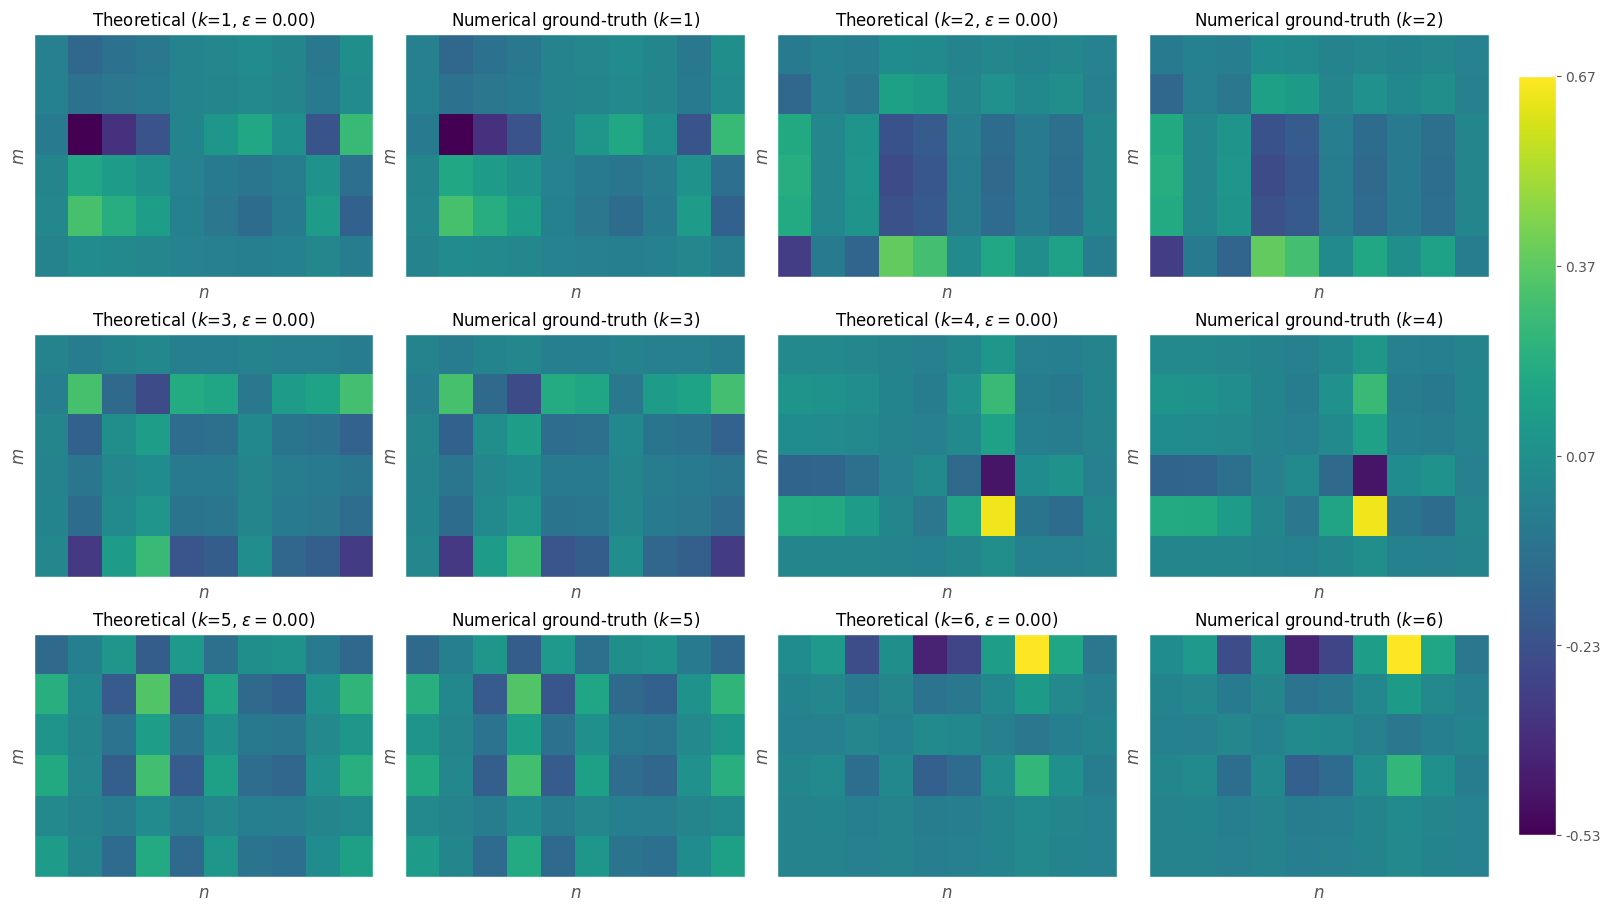

In [6]:
torch.manual_seed(1)

m = 6   # Number of rows
n = 10  # Number of columns

A = torch.randn(m, n, dtype=torch.double, requires_grad=True)

J_normal_res_list = get_singularvalue_Jacobians(A)

plot_pairs(res_list=J_normal_res_list, 
                    saveto="jacobian_normal.pdf", 
                    show_cbar=True, 
                    cmap="viridis")

## Uniform distribution

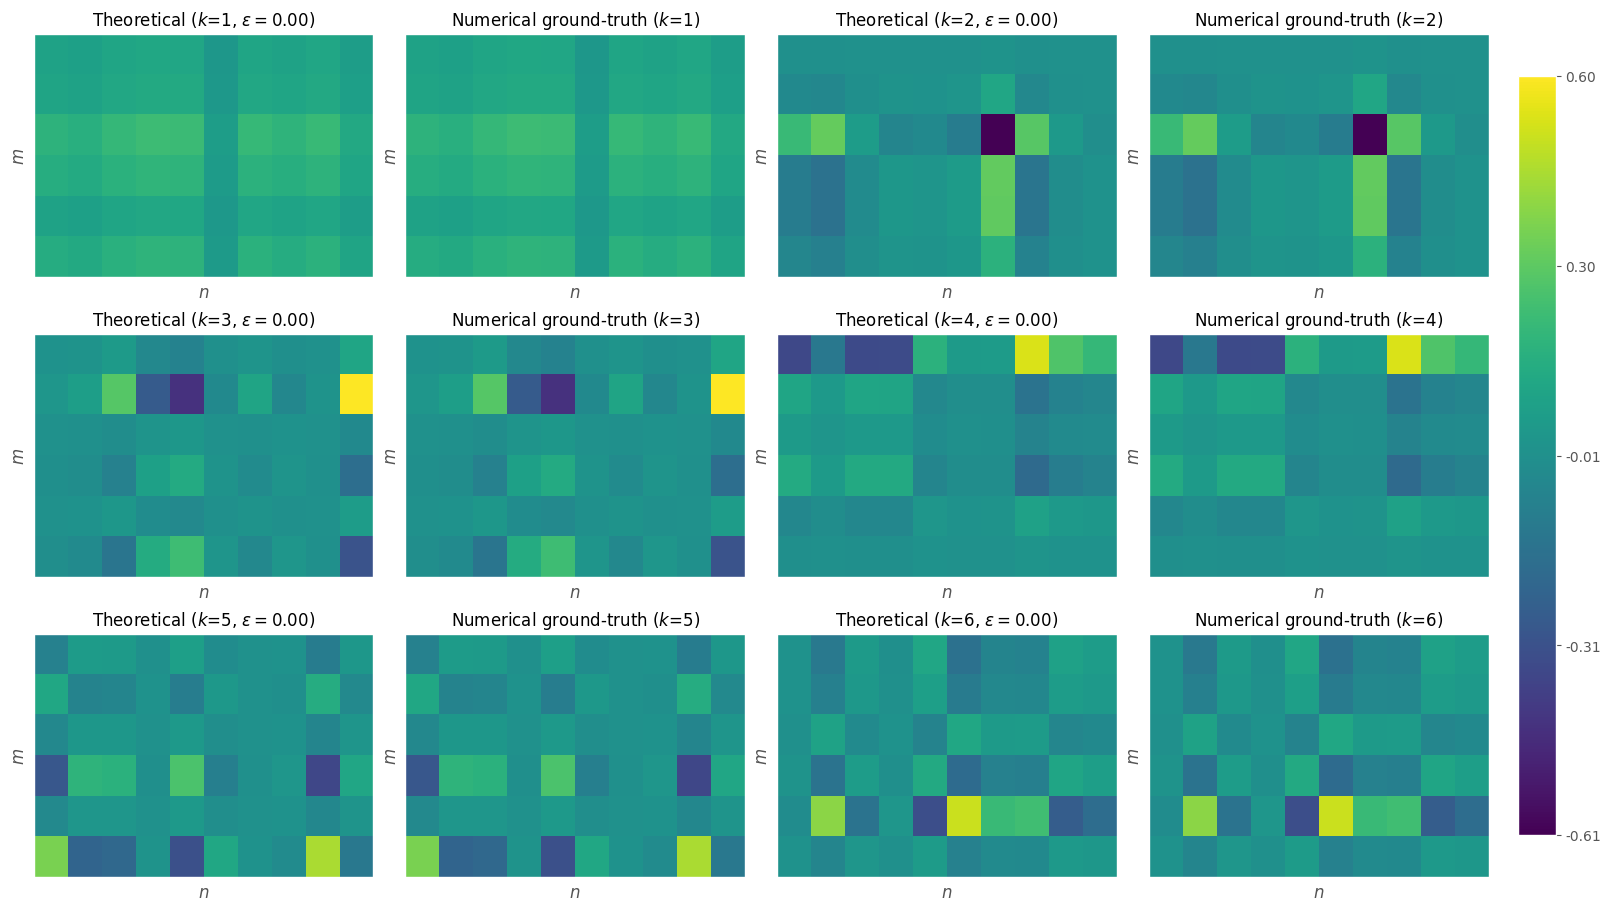

In [7]:
torch.manual_seed(1)

m = 6   # Number of rows
n = 10  # Number of columns

A = torch.rand(m, n, dtype=torch.double, requires_grad=True)

J_uniform_res_list = get_singularvalue_Jacobians(A)

plot_pairs(res_list=J_uniform_res_list, 
                    saveto="jacobian_uniform.pdf", 
                    show_cbar=True, 
                    cmap="viridis")

## Beta distribution

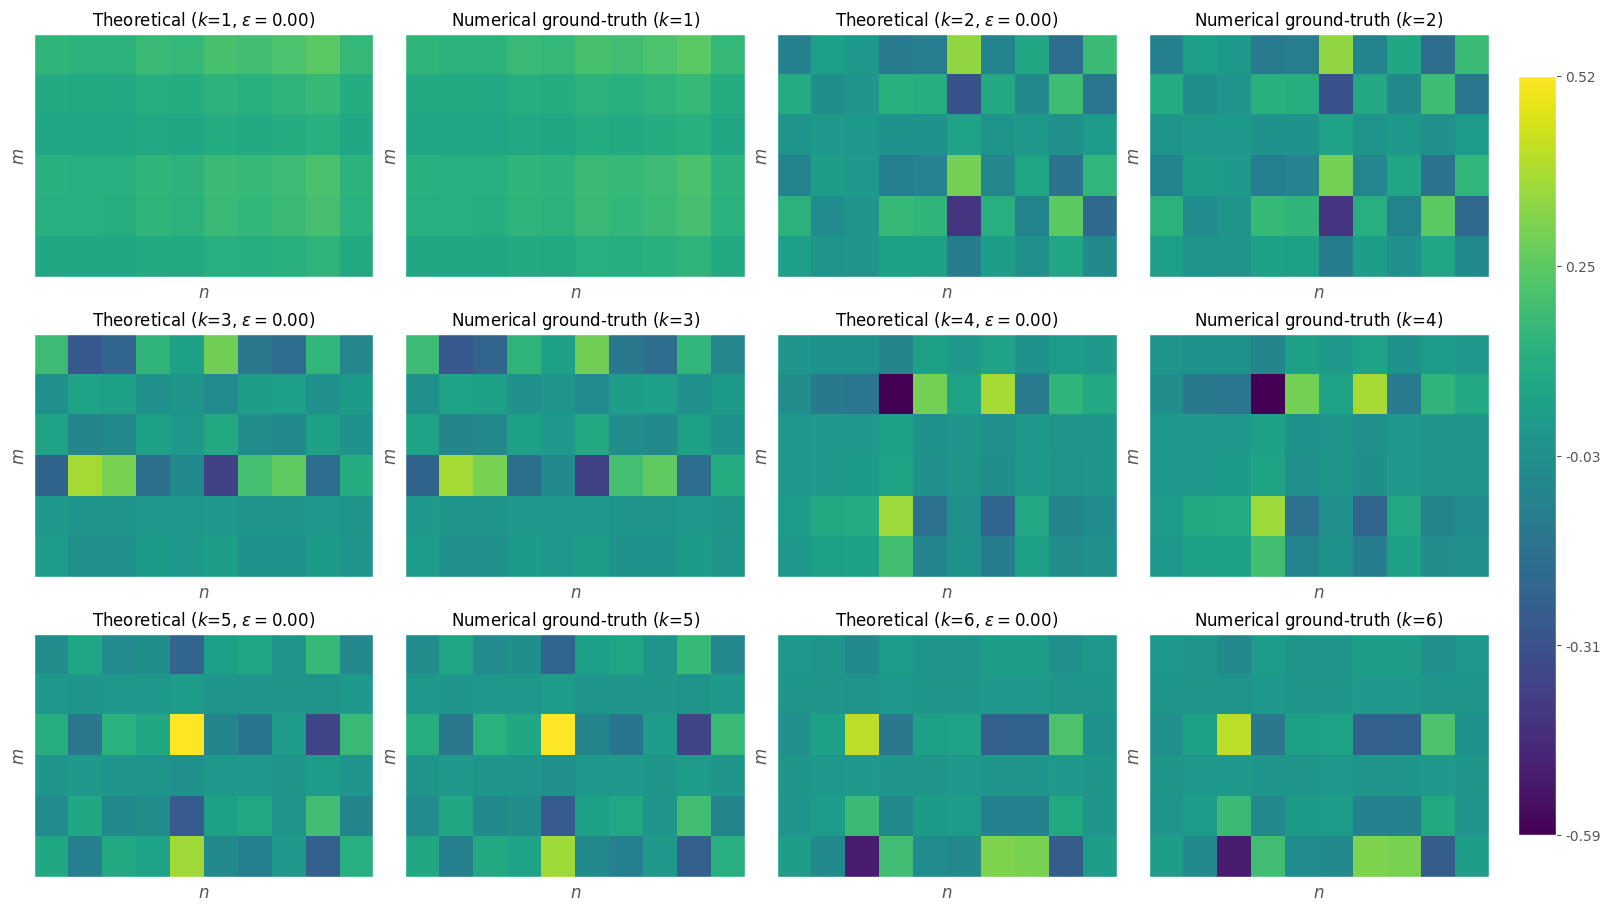

In [8]:
from torch.distributions import Beta

torch.manual_seed(1)

m = 6   # Number of rows
n = 10  # Number of columns

A = Beta(2., 5.).sample((m, n)).double().requires_grad_(True)

J_beta_res_list = get_singularvalue_Jacobians(A)


plot_pairs(res_list=J_beta_res_list, 
                    saveto="jacobian_beta.pdf", 
                    show_cbar=True, 
                    cmap="viridis")

# Singular-Value Hessian

In [9]:
def singular_value_hessian_full(U, S, Vh, k):
    sigma_k = S[k - 1].item()
    
    u_k = U[:, k - 1] 
    v_k = Vh[k - 1, :] 
    
    m = U.size(0)
    n = Vh.size(0)
    
    H = torch.zeros((m*n, m*n), dtype=torch.float64)

    #left bases
    for i in range(m):
        if i == k - 1:
            continue
        
        if i >= len(S):
            sigma_i = 0
        else:
            sigma_i = S[i].item()

        coeff = sigma_k / (sigma_k**2 - sigma_i**2)

        v_k = Vh[k - 1, :]  
        u_i = U[:, i]  

        kron_vk_ui = torch.kron(v_k, u_i)  
    
        H += coeff * torch.outer(kron_vk_ui, kron_vk_ui) 

    #right bases
    for j in range(n):
        if j == k - 1:
            continue
        
        if j >= len(S):
            sigma_j = 0
        else:
            sigma_j = S[j].item()

        coeff = sigma_k / (sigma_k**2 - sigma_j**2)

        v_j = Vh[j, :]  
        u_k = U[:, k - 1]  

        kron_vj_uk = torch.kron(v_j, u_k)  
    
        H += coeff * torch.outer(kron_vj_uk, kron_vj_uk) 


    # cross terms.
    for l in range(len(S)):
        if l == k - 1:
            continue
        
        sigma_l = S[l].item()
        u_l = U[:, l]  
        v_l = Vh[l, :]  

        coeff = sigma_l / (sigma_k**2 - sigma_l**2)


        # Compute the Kronecker products
        kron_vk_ul = torch.kron(v_k, u_l)      
        kron_vl_uk = torch.kron(v_l, u_k)  

     
        # Add to the theoretical Hessian
        H += coeff * torch.outer(kron_vk_ul, kron_vl_uk) 
        H += coeff * torch.outer(kron_vl_uk, kron_vk_ul)
    
    return H

In [36]:
def get_singularvalue_Hessian(A, k):    
    m, n = A.shape

    A_vec = vec(A).detach()
    A_vec.requires_grad = True

    
    def sigma_func(X_vec):
        X_mat = unvec(X_vec, shape=(m, n))
        U, S, Vh = torch.linalg.svd(X_mat, full_matrices=True)
        return S[k - 1]


    H_autograd = torch.autograd.functional.hessian(sigma_func, A_vec).detach()

    A_mat = unvec(A_vec.detach(), shape=(m, n)).detach()
    
    U, S, Vh = torch.linalg.svd(A_mat.detach(), full_matrices=True)

    H_theoretical = singular_value_hessian_full(U, S, Vh, k = k)

    U, S, Vh = torch.linalg.svd(A.detach(), full_matrices=True)

    H_error = torch.norm(H_theoretical - H_autograd)
    
    return k, H_theoretical.detach().numpy(), H_autograd.detach().numpy(), H_error.item()

def get_singularvalue_Hessians(A): 
    r = torch.linalg.matrix_rank(A)
    res_list=[]
    
    for k in range(1, r+1):
        A_local = A.clone().detach()
        A_local.requires_grad_()    
        res = get_singularvalue_Hessian(A_local, k)
        res_list.append(res)
        
    return res_list

## Gaussian distribution

error:  3.600634566153391e-16
error:  5.216695766906811e-16
error:  8.104844108064441e-16
error:  1.1449001589062293e-15
error:  1.3033015208086647e-15
error:  1.472132910691209e-15


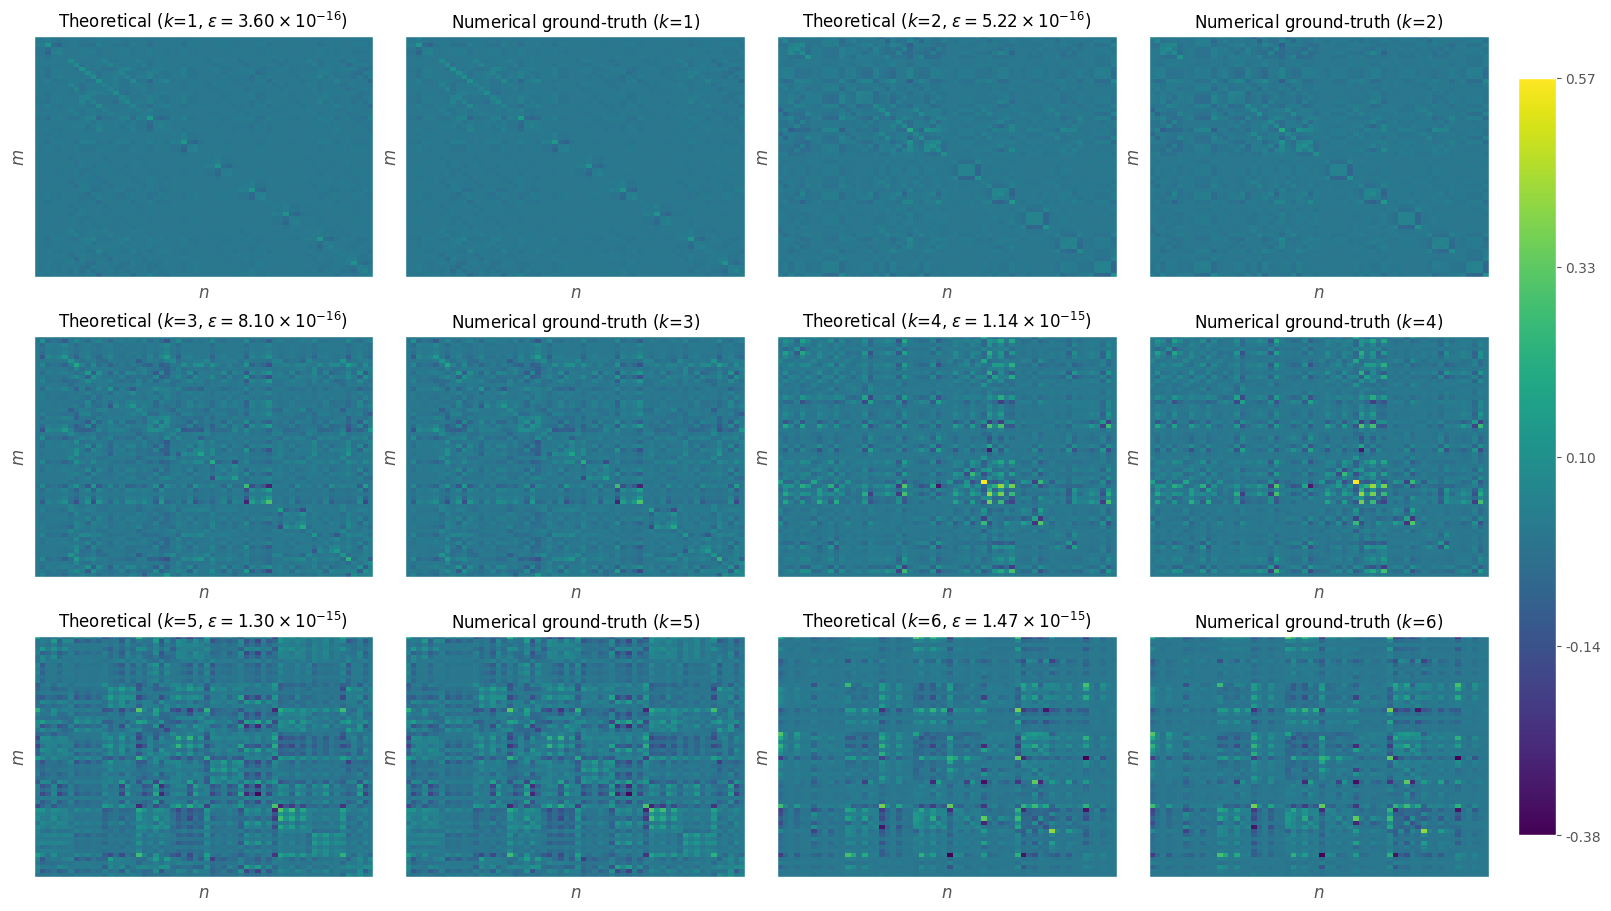

In [37]:
torch.manual_seed(1)

m = 6   # Number of rows
n = 10   # Number of columns

A = torch.randn(m, n, dtype=torch.double, requires_grad=True)

H_normal_res_list = get_singularvalue_Hessians(A)

plot_pairs(res_list=H_normal_res_list, 
                    saveto="hessian_normal.pdf", 
                    show_cbar=True, 
                    cmap="viridis")

## Errors in Gaussian distribution

In [44]:
def get_Hessian_errors(matrix_sampler: callable, seed=1, m=6, n=10, max_trials=200):
    #torch.manual_seed(seed)

    errs_list=[]
    for _ in tqdm(range(max_trials)):
        
        A = matrix_sampler(m, n)
        
        res_list = get_singularvalue_Hessians(A)
        for res in res_list:
            errs_list.append((res[0], res[-1]))
            
    return np.array(errs_list)

def plot_errors(errs_list, savename=None, cmap="tab10"):
    # make sure plots/ exists
    os.makedirs("plots", exist_ok=True)

    df = pd.DataFrame(H_normal_errs, columns=[r"$k$", r"$\epsilon$"])
    df[r"$k$"] = df[r"$k$"].astype(int) 

    # --- plot KDE curves per k
    palette = plt.cm.get_cmap("tab10")
    plt.figure(figsize=(7, 5))

    sns.kdeplot(data=df, 
                x=r"$\epsilon$", hue=r"$k$", 
                common_norm=False, 
                fill=False, lw=2, palette=palette)

    plt.xlabel(r"$\epsilon$")
    plt.ylabel("Density")

    #plt.legend(title=r"$k$", ncol=2, fontsize=9)
    
    # save as PDF at dpi=160
    if savename:
        save_path = os.path.join("plots", savename)
        plt.savefig(save_path, dpi=160, format="pdf", bbox_inches="tight")

    plt.tight_layout()

    plt.title("Density of Hessian Errors by Singular Value Index")
    plt.show()

In [30]:
def normal_matrix_sampler(m, n):
    A = torch.randn(m, n, dtype=torch.double, requires_grad=True)
    return A
    
H_normal_errs = get_Hessian_errors(matrix_sampler=normal_matrix_sampler, 
                                   seed=1, m=6, n=10, max_trials=500)

  0%|          | 0/500 [00:00<?, ?it/s]

/var/folders/dn/9hd476xj1xj2q9k1gw_sh0nc0000gn/T/ipykernel_91164/3620025180.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10")


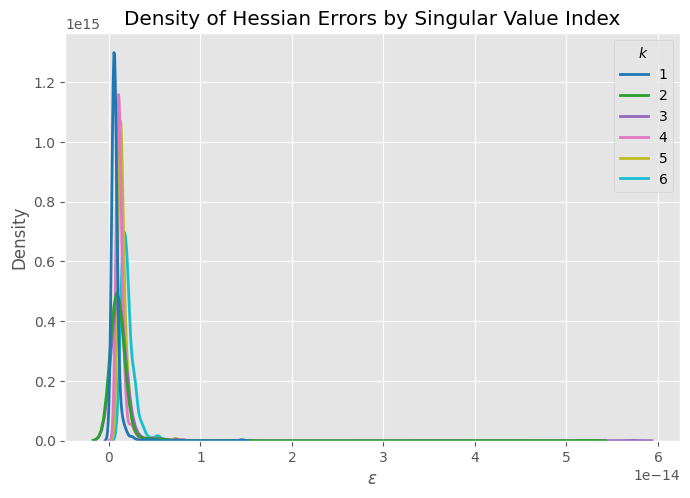

In [45]:
plot_errors(H_normal_errs, savename="hessian_error_density_normal.pdf", cmap="Set1")

## Uniform distribution

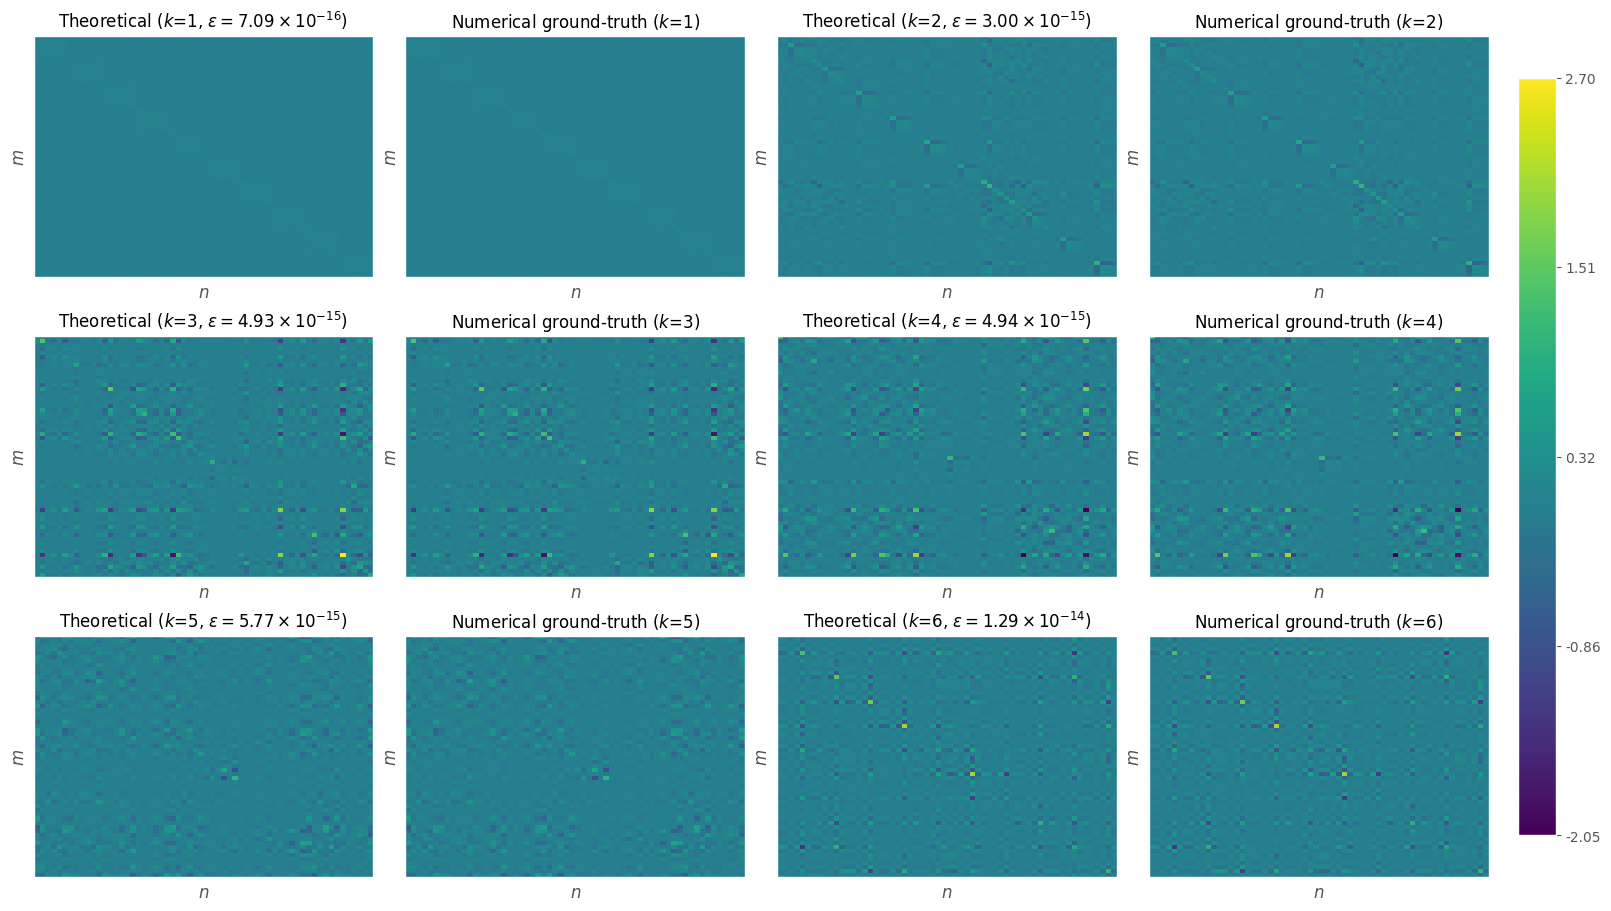

In [24]:
torch.manual_seed(1)

m = 6   # Number of rows
n = 10  # Number of columns

A = torch.rand(m, n, dtype=torch.double, requires_grad=True)

H_uniform_res_list = get_singularvalue_Hessians(A)

plot_pairs(res_list=H_uniform_res_list, 
                    saveto="hessian_uniform.pdf", 
                    show_cbar=True, 
                    cmap="viridis")

In [32]:
def uniform_matrix_sampler(m, n):
    A = torch.rand(m, n, dtype=torch.double, requires_grad=True)
    return A
    

H_uniform_errs = get_Hessian_errors(matrix_sampler=uniform_matrix_sampler, 
                                    seed=1, m=6, n=10, max_trials=500)

  0%|          | 0/500 [00:00<?, ?it/s]

/var/folders/dn/9hd476xj1xj2q9k1gw_sh0nc0000gn/T/ipykernel_91164/1068999388.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10")


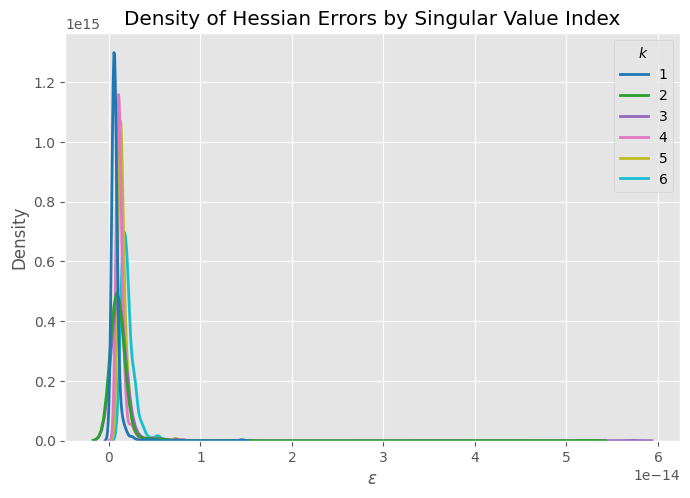

In [33]:
plot_errors(H_uniform_errs, savename="hessian_error_density_uniform.pdf", cmap="Set1")

## Beta distribution

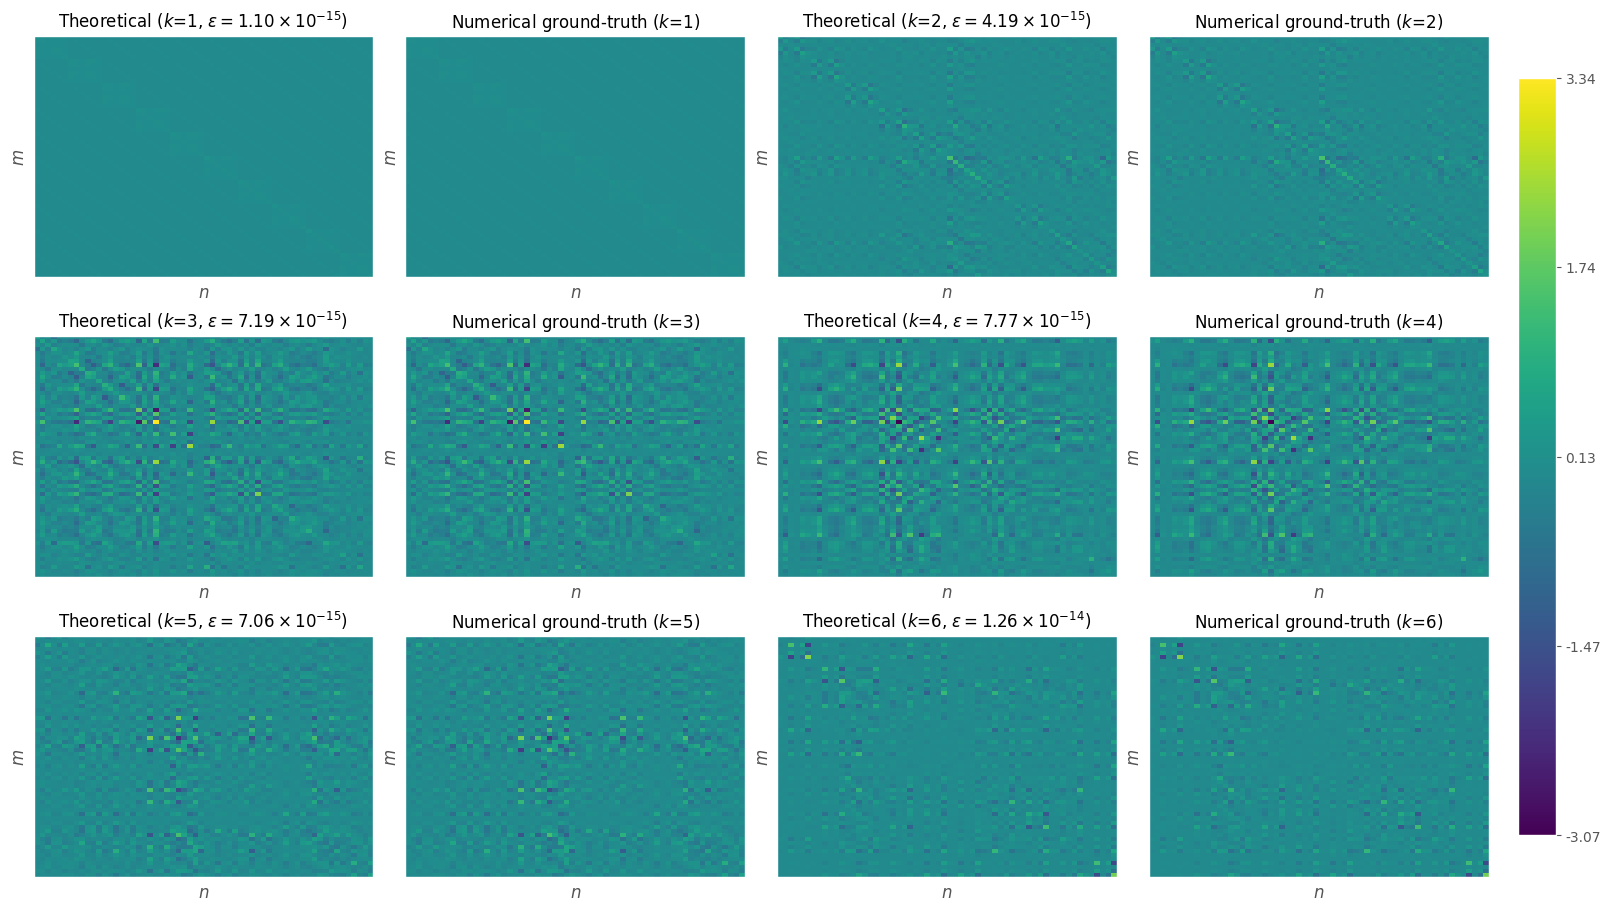

In [27]:
torch.manual_seed(1)

m = 6   # Number of rows
n = 10  # Number of columns

A = Beta(2., 5.).sample((m, n)).double().requires_grad_(True)

H_beta_res_list = get_singularvalue_Hessians(A)

plot_pairs(res_list=H_beta_res_list, 
                    saveto="hessian_beta.pdf", 
                    show_cbar=True, 
                    cmap="viridis")

In [34]:
def beta_matrix_sampler(m, n):
    A = Beta(2., 5.).sample((m, n)).double().requires_grad_(True)
    return A
    

H_beta_errs = get_Hessian_errors(matrix_sampler=beta_matrix_sampler, 
                                    seed=1, m=6, n=10, max_trials=500)

  0%|          | 0/500 [00:00<?, ?it/s]

/var/folders/dn/9hd476xj1xj2q9k1gw_sh0nc0000gn/T/ipykernel_91164/1068999388.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10")


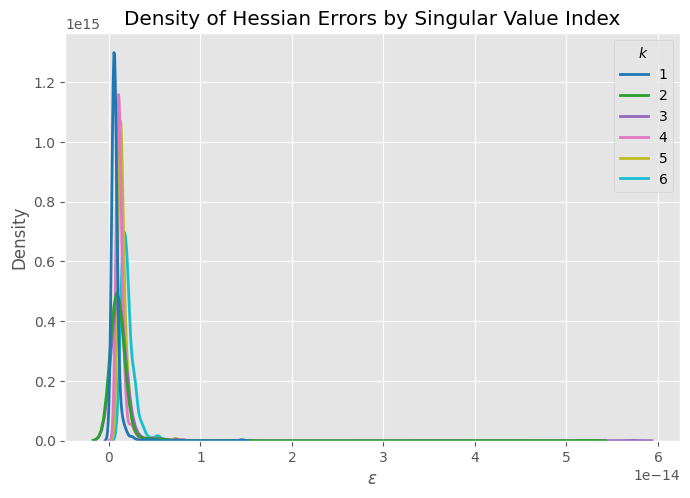

In [35]:
plot_errors(H_beta_errs, savename="hessian_error_density_beta.pdf", cmap="Set1")